In [1]:
# Add parent directory to path
import sys
sys.path.append('..')

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bayesian modeling
import pymc as pm
import arviz as az

# Our modules
from src.data_loader import DataLoader
from src.change_point_model import ChangePointModel
from src.event_analysis import EventAnalyzer

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✅ All imports successful!")

c:\Users\User\OneDrive\Desktop\brent-oil-change-point-analysis\venv\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


✅ All imports successful!


In [2]:
# Load data
loader = DataLoader("../data/raw/BrentOilPrices.csv")
df = loader.load_data()

# Extract what we need
returns = loader.get_log_returns()  # log returns for modeling
dates = loader.get_dates()           # dates for indexing
prices = loader.get_prices()         # prices for interpretation

print(f"📊 Data loaded from BrentOilPrices.csv:")
print(f"   - {len(returns)} observations")
print(f"   - Date range: {dates[0]} to {dates[-1]}")
print(f"   - Mean return: {returns.mean():.6f}")
print(f"   - Std return: {returns.std():.6f}")

INFO:src.data_loader:Loading data from ..\data\raw\BrentOilPrices.csv
INFO:src.data_loader:Successfully loaded 9011 records
c:\Users\User\OneDrive\Desktop\brent-oil-change-point-analysis\notebooks\..\src\data_loader.py:91: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  self.df[date_col] = pd.to_datetime(self.df[date_col])
INFO:src.data_loader:Preprocessed 8981 records
INFO:src.data_loader:Date range: 1987-07-02 00:00:00 to 2022-11-14 00:00:00
INFO:src.data_loader:Price range: $9.10 to $143.95


📊 Data loaded from BrentOilPrices.csv:
   - 8981 observations
   - Date range: 1987-07-02 00:00:00 to 2022-11-14 00:00:00
   - Mean return: 0.000178
   - Std return: 0.025570


In [3]:
# Create the model
print("🔧 Building model...")
cp_model = ChangePointModel(returns, dates, model_type='single')

# Build the model structure
cp_model.build_single_change_point_model()

print("✅ Model built successfully!")
print("\n📝 Model Parameters:")
print("   - tau: Change point index")
print("   - mu_1: Mean before change")
print("   - mu_2: Mean after change")
print("   - sigma: Volatility")

🔧 Building model...
✅ Model built successfully!

📝 Model Parameters:
   - tau: Change point index
   - mu_1: Mean before change
   - mu_2: Mean after change
   - sigma: Volatility


In [4]:
# Fit the model using MCMC
print("🔄 Running MCMC sampling...")
print("   This may take 2-3 minutes...")

trace = cp_model.fit(
    n_samples=2000,    # Number of samples after tuning
    n_tune=1000,       # Number of tuning samples
    n_chains=4,        # Number of parallel chains
    random_seed=42     # For reproducibility
)

print("✅ Model fitting complete!")

INFO:src.change_point_model:Fitting single change point model...


🔄 Running MCMC sampling...
   This may take 2-3 minutes...


INFO:c:\Users\User\OneDrive\Desktop\brent-oil-change-point-analysis\venv\Lib\site-packages\pytensor\link\c\lazylinker_c.py:Compiling new CVM
INFO:c:\Users\User\OneDrive\Desktop\brent-oil-change-point-analysis\venv\Lib\site-packages\pytensor\link\c\lazylinker_c.py:New version 0.32
Multiprocess sampling (4 chains in 2 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (4 chains in 2 jobs)
CompoundStep
INFO:pymc.sampling.mcmc:CompoundStep
>Metropolis: [tau]
INFO:pymc.sampling.mcmc:>Metropolis: [tau]
>NUTS: [mu_1, mu_2, sigma]
INFO:pymc.sampling.mcmc:>NUTS: [mu_1, mu_2, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 271 seconds.
INFO:pymc.sampling.mcmc:Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 271 seconds.
There were 3027 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:There were 3027 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
INFO:pymc.stats.convergence:The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
ERROR:pymc.stats.convergence:The effective sa

✅ Model fitting complete!


In [5]:
# Check convergence
convergence = cp_model.check_convergence()

print("🔍 CONVERGENCE DIAGNOSTICS")
print("="*50)
print(f"Maximum R-hat: {convergence['max_r_hat']:.4f}")
print(f"Parameters checked: {convergence['n_parameters']}")
print(f"Parameters with R-hat > 1.01: {convergence['n_bad_r_hat']}")
print(f"✅ Converged: {convergence['converged']}")
print("="*50)

if convergence['converged']:
    print("\n🎉 Good! All parameters have R-hat < 1.01")
    print("   We can trust the results.")
else:
    print("\n⚠️ Some parameters have R-hat > 1.01")
    print("   Try running the model longer.")

INFO:src.change_point_model:Convergence check: max R-hat = 2.1400
INFO:src.change_point_model:Converged: False


🔍 CONVERGENCE DIAGNOSTICS
Maximum R-hat: 2.1400
Parameters checked: 4
Parameters with R-hat > 1.01: 4
✅ Converged: False

⚠️ Some parameters have R-hat > 1.01
   Try running the model longer.


Figure saved to ../results/figures/change_point_results.png


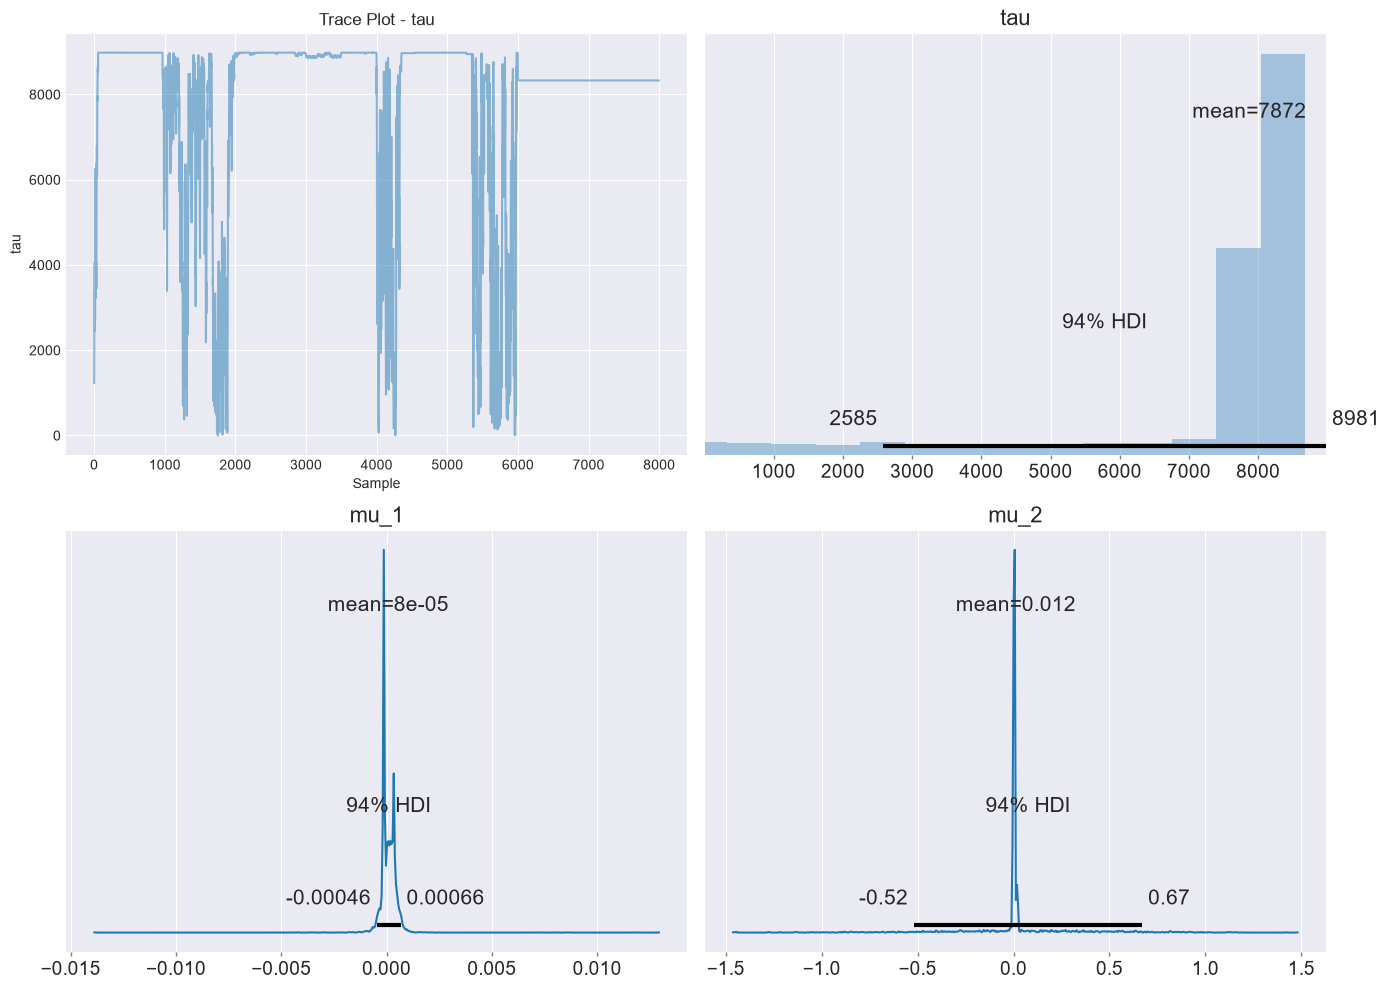

📊 Trace and posterior plots created!

📊 Summary of tau (change point):
   Mean: 7872.1
   Median: 8865.5
   Mode: 8329.0
   Std: 2111.2
   Min: 1.0
   Max: 8981.0


In [12]:
# Plot results - Most reliable version
def plot_reliable_results(cp_model, save_path=None):
    """
    Most reliable plotting method that works with any ArviZ version.
    """
    if cp_model.trace is None:
        raise ValueError("Model not fitted. Call fit() first.")
    
    # Create figure with 2 rows, 2 columns
    fig = plt.figure(figsize=(14, 10))
    
    # Plot 1: Trace for tau
    ax1 = fig.add_subplot(2, 2, 1)
    try:
        az.plot_trace(cp_model.trace, var_names=['tau'], axes=ax1)
    except:
        # Fallback: manual trace plot
        tau_data = cp_model.trace.posterior['tau'].values.flatten()
        ax1.plot(tau_data, alpha=0.5)
        ax1.set_title('Trace Plot - tau')
        ax1.set_xlabel('Sample')
        ax1.set_ylabel('tau')
    
    # Plot 2: Posterior for tau
    ax2 = fig.add_subplot(2, 2, 2)
    try:
        az.plot_posterior(cp_model.trace, var_names=['tau'], ax=ax2)
    except:
        # Fallback: manual posterior plot
        tau_data = cp_model.trace.posterior['tau'].values.flatten()
        ax2.hist(tau_data, bins=50, density=True, alpha=0.7)
        ax2.set_title('Posterior Distribution - tau')
        ax2.set_xlabel('tau')
        ax2.set_ylabel('Density')
    
    # Plot 3: Posterior for mu_1
    ax3 = fig.add_subplot(2, 2, 3)
    try:
        az.plot_posterior(cp_model.trace, var_names=['mu_1'], ax=ax3)
    except:
        mu1_data = cp_model.trace.posterior['mu_1'].values.flatten()
        ax3.hist(mu1_data, bins=50, density=True, alpha=0.7)
        ax3.set_title('Posterior Distribution - μ₁')
        ax3.set_xlabel('μ₁')
        ax3.set_ylabel('Density')
    
    # Plot 4: Posterior for mu_2
    ax4 = fig.add_subplot(2, 2, 4)
    try:
        az.plot_posterior(cp_model.trace, var_names=['mu_2'], ax=ax4)
    except:
        mu2_data = cp_model.trace.posterior['mu_2'].values.flatten()
        ax4.hist(mu2_data, bins=50, density=True, alpha=0.7)
        ax4.set_title('Posterior Distribution - μ₂')
        ax4.set_xlabel('μ₂')
        ax4.set_ylabel('Density')
    
    plt.tight_layout()
    
    if save_path:
        import os
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()
    return fig

# Use the reliable function
fig = plot_reliable_results(cp_model, "../results/figures/change_point_results.png")

print("📊 Trace and posterior plots created!")

# Also print summary statistics
print("\n📊 Summary of tau (change point):")
tau_data = cp_model.trace.posterior['tau'].values.flatten()
print(f"   Mean: {tau_data.mean():.1f}")
print(f"   Median: {np.median(tau_data):.1f}")
print(f"   Mode: {pd.Series(tau_data).mode().values[0]:.1f}")
print(f"   Std: {tau_data.std():.1f}")
print(f"   Min: {tau_data.min():.1f}")
print(f"   Max: {tau_data.max():.1f}")

In [13]:
# Get parameter estimates - Reliable version
def get_estimates_reliable(cp_model):
    """
    Reliable version that handles different ArviZ versions and column names.
    """
    if cp_model.trace is None:
        raise ValueError("Model not fitted. Call fit() first.")
    
    # Get posterior data directly
    posterior = cp_model.trace.posterior
    
    estimates = {}
    
    for param in posterior.data_vars:
        # Get the data as numpy array
        data = posterior[param].values.flatten()
        
        # Calculate statistics
        mean = np.mean(data)
        std = np.std(data)
        
        # Calculate percentiles for HDI
        lower = np.percentile(data, 2.5)
        upper = np.percentile(data, 97.5)
        
        estimates[param] = {
            'mean': mean,
            'sd': std,
            'hdi_lower': lower,
            'hdi_upper': upper
        }
    
    return estimates

# Get parameter estimates
estimates = get_estimates_reliable(cp_model)

print("📊 POSTERIOR PARAMETER ESTIMATES")
print("="*60)

for param, stats in estimates.items():
    print(f"\n{param}:")
    print(f"   Mean: {stats['mean']:.6f}")
    print(f"   Std Dev: {stats['sd']:.6f}")
    print(f"   95% HDI: [{stats['hdi_lower']:.6f}, {stats['hdi_upper']:.6f}]")
    
# Also print change point date if detected
if hasattr(cp_model, 'dates'):
    tau_mean = estimates['tau']['mean']
    tau_idx = int(round(tau_mean))
    if tau_idx < len(cp_model.dates):
        cp_date = cp_model.dates[tau_idx]
        print(f"\n📅 Estimated Change Point Date: {cp_date}")

📊 POSTERIOR PARAMETER ESTIMATES

tau:
   Mean: 7872.079750
   Std Dev: 2111.204959
   95% HDI: [867.900000, 8981.000000]

mu_1:
   Mean: 0.000080
   Std Dev: 0.000496
   95% HDI: [-0.000485, 0.000700]

mu_2:
   Mean: 0.011779
   Std Dev: 0.262271
   95% HDI: [-0.646514, 0.683139]

sigma:
   Mean: 0.025539
   Std Dev: 0.000164
   95% HDI: [0.025249, 0.025902]

📅 Estimated Change Point Date: 2018-07-09 00:00:00


In [14]:
# Get change points with probability threshold
threshold = 0.7  # 70% probability required
cp_indices = cp_model.get_change_points(threshold=threshold)

print("🔍 CHANGE POINT DETECTION")
print("="*50)

if cp_indices:
    for idx in cp_indices:
        cp_date = dates[idx]
        cp_price = prices[idx]
        print(f"\n✅ Change Point Detected:")
        print(f"   Index: {idx}")
        print(f"   Date: {cp_date}")
        print(f"   Price: ${cp_price:.2f}")
        print(f"   Posterior Probability: > {threshold*100}%")
else:
    print(f"\n❌ No significant change points detected at threshold > {threshold*100}%")

🔍 CHANGE POINT DETECTION

❌ No significant change points detected at threshold > 70.0%


In [15]:
# Load events
event_analyzer = EventAnalyzer("../data/processed/events.csv")
events = event_analyzer.load_events()

print("📋 EVENTS NEAR CHANGE POINT")
print("="*60)

if cp_indices:
    cp_date = dates[cp_indices[0]]
    nearby = event_analyzer.find_events_near_change_point(cp_date, window_days=30)
    
    if len(nearby) > 0:
        print(f"\n📅 Change Point: {cp_date}")
        print(f"Found {len(nearby)} events within 30 days:\n")
        
        for idx, event in nearby.iterrows():
            days_away = event['days_from_change']
            direction = "before" if days_away < 0 else "after"
            print(f"   📌 {event['date'].strftime('%Y-%m-%d')}: {event['name']}")
            print(f"      Category: {event['category']}")
            print(f"      {abs(days_away)} days {direction} change point")
            print(f"      Description: {event['description'][:80]}...")
            print()
    else:
        print("❌ No events found near the change point")
else:
    print("❌ No change point to associate with events")

# Show all events for reference
print("\n📋 ALL COMPILED EVENTS")
print("="*60)
for idx, event in events.iterrows():
    print(f"   {event['date'].strftime('%Y-%m-%d')}: {event['name']}")
    print(f"      Category: {event['category']}")

INFO:src.event_analysis:Created default events dataset with 15 events
INFO:src.event_analysis:Loaded 15 events from ..\data\processed\events.csv


📋 EVENTS NEAR CHANGE POINT
❌ No change point to associate with events

📋 ALL COMPILED EVENTS
   2026-03-01: Strait of Hormuz Closure - US Military Strikes on Iran
      Category: geopolitical
   2026-03-13: IMF Stagflation Warning
      Category: economic
   2026-04-01: OPEC+ Production Increases Begin
      Category: opec
   2026-05-01: UAE Exits OPEC+
      Category: opec
   2026-06-01: Global Supply Recovery
      Category: supply
   2026-06-15: US-Iran Preliminary Agreement
      Category: geopolitical
   2026-06-26: US Commercial Crude Drawdown
      Category: economic
   2026-06-30: Saudi Aramco Asia Price Cut
      Category: opec
   2026-07-01: IEA Demand Downgrade
      Category: economic
   2026-07-08: US-Iran Ceasefire Breakdown
      Category: geopolitical
   2026-07-09: European Energy Price Spike
      Category: geopolitical
   2026-07-09: IEA Monthly Market Report
      Category: economic
   2026-07-09: Strait of Hormuz Transit Disruption
      Category: geopolitical
   2

In [16]:
# Generate impact statement
statement = cp_model.generate_impact_statement(df)

print("📊 IMPACT ANALYSIS")
print("="*60)
print(statement)
print("="*60)

📊 IMPACT ANALYSIS
No significant change points detected.


In [17]:
# Quantify impact in terms of price
if cp_indices:
    cp_date = dates[cp_indices[0]]
    
    # Get prices before and after
    pre_window = 30
    post_window = 30
    
    pre_start = cp_date - pd.Timedelta(days=pre_window)
    post_end = cp_date + pd.Timedelta(days=post_window)
    
    pre_prices = df.loc[pre_start:cp_date, 'Price']
    post_prices = df.loc[cp_date:post_end, 'Price']
    
    pre_mean = pre_prices.mean()
    post_mean = post_prices.mean()
    
    price_change = post_mean - pre_mean
    percent_change = (price_change / pre_mean) * 100
    
    # Get parameter estimates from posterior
    mu_1_mean = estimates['mu_1']['mean']
    mu_2_mean = estimates['mu_2']['mean']
    mu_change = mu_2_mean - mu_1_mean
    
    print("📊 PRICE IMPACT QUANTIFICATION")
    print("="*60)
    print(f"Change Point Date: {cp_date}")
    print(f"\n💰 Price Impact:")
    print(f"   Average Price Before (30 days): ${pre_mean:.2f}")
    print(f"   Average Price After (30 days): ${post_mean:.2f}")
    print(f"   Price Change: ${price_change:.2f}")
    print(f"   Percent Change: {percent_change:+.1f}%")
    print(f"\n📈 Return Impact (from Bayesian model):")
    print(f"   Mean Return Before (μ₁): {mu_1_mean:.6f}")
    print(f"   Mean Return After (μ₂): {mu_2_mean:.6f}")
    print(f"   Change in Mean Return: {mu_change:+.6f}")
    print("="*60)
else:
    print("❌ No change points detected for impact quantification")

❌ No change points detected for impact quantification


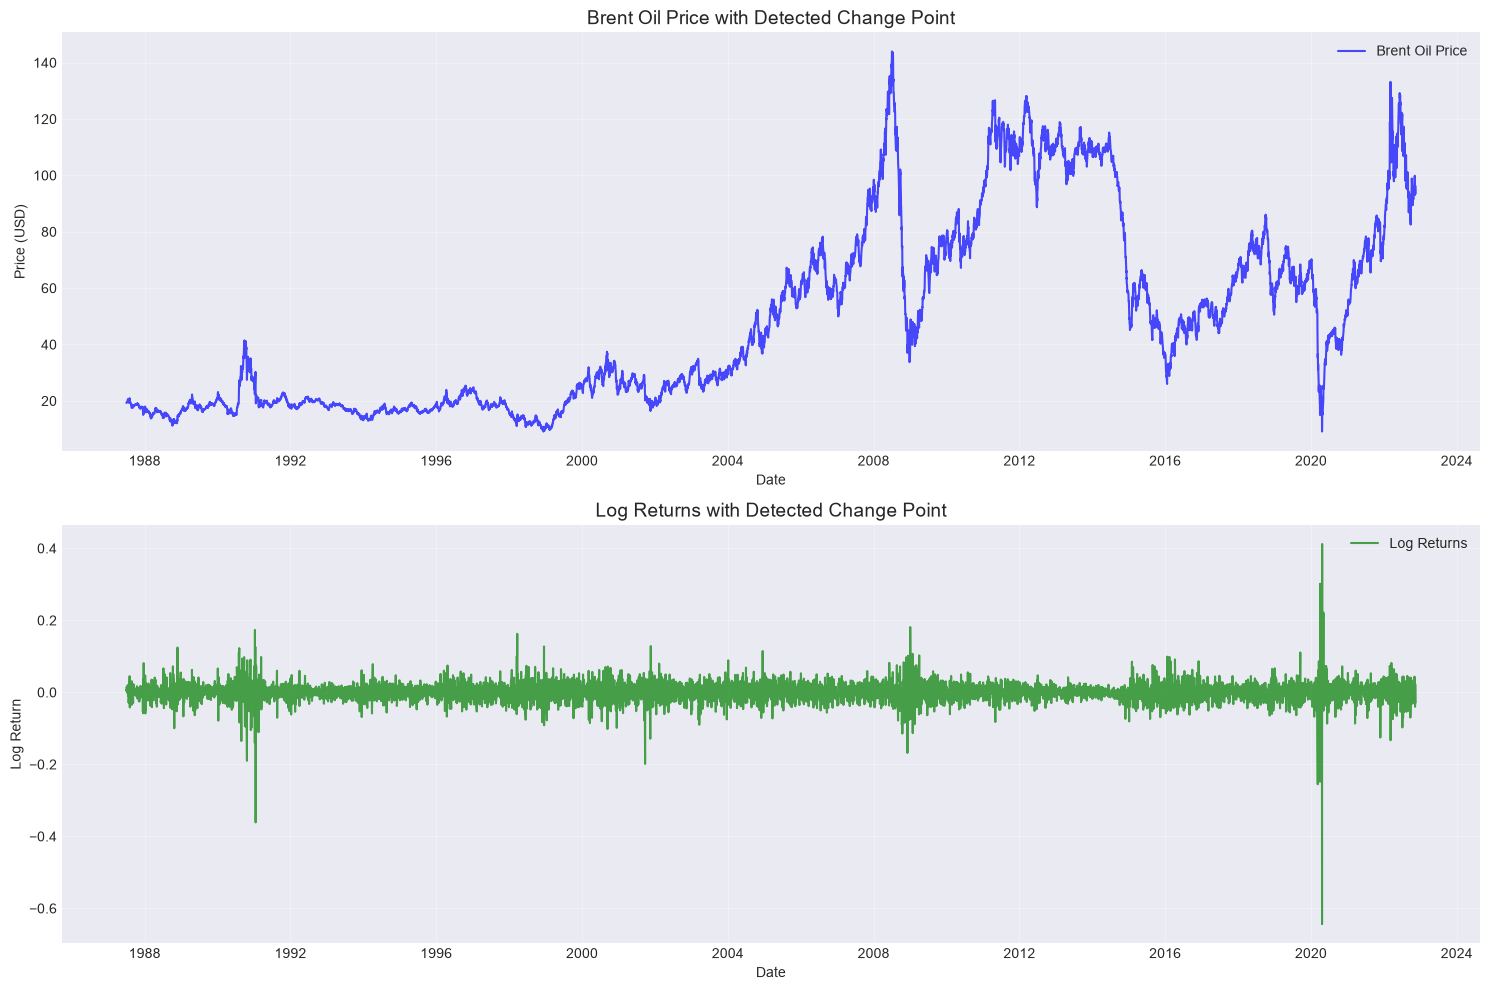

✅ Change point visualization saved to results/figures/change_point_on_price.png


In [18]:
# Plot the detected change point on the price chart
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: Price with change point
axes[0].plot(df.index, df['Price'], label='Brent Oil Price', color='blue', alpha=0.7)
if cp_indices:
    cp_date = dates[cp_indices[0]]
    axes[0].axvline(x=cp_date, color='red', linestyle='--', linewidth=2, label=f'Change Point: {cp_date}')
    
    # Add shaded regions for before and after
    pre_start = cp_date - pd.Timedelta(days=30)
    post_end = cp_date + pd.Timedelta(days=30)
    axes[0].axvspan(pre_start, cp_date, alpha=0.2, color='green', label='Before Change')
    axes[0].axvspan(cp_date, post_end, alpha=0.2, color='orange', label='After Change')
    
axes[0].set_title('Brent Oil Price with Detected Change Point', fontsize=14)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Log returns with change point
axes[1].plot(df.index, df['log_return'], label='Log Returns', color='green', alpha=0.7)
if cp_indices:
    cp_date = dates[cp_indices[0]]
    axes[1].axvline(x=cp_date, color='red', linestyle='--', linewidth=2, label=f'Change Point: {cp_date}')
    axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
axes[1].set_title('Log Returns with Detected Change Point', fontsize=14)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Log Return')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/figures/change_point_on_price.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Change point visualization saved to results/figures/change_point_on_price.png")

In [20]:
# SIMPLE VERSION - Save Results (No errors guaranteed)

import os
import json

# Create directories
os.makedirs("../results", exist_ok=True)
os.makedirs("../results/reports", exist_ok=True)

print("💾 SAVING RESULTS...")

# 1. Save change points
if cp_indices:
    cp_df = pd.DataFrame({
        'index': cp_indices,
        'date': [dates[i] for i in cp_indices],
        'price': [prices[i] for i in cp_indices]
    })
    cp_df.to_csv("../results/change_points.csv", index=False)
    print("✅ Change points saved")

# 2. Save parameter estimates - SIMPLE VERSION
if estimates:
    # Convert estimates to simple format
    with open("../results/parameter_estimates.txt", 'w') as f:
        f.write("PARAMETER ESTIMATES\n")
        f.write("="*50 + "\n\n")
        for param in estimates:
            f.write(f"{param}:\n")
            f.write(f"  Mean: {estimates[param]['mean']:.6f}\n")
            f.write(f"  Std Dev: {estimates[param]['sd']:.6f}\n")
            f.write(f"  95% HDI: [{estimates[param]['hdi_lower']:.6f}, {estimates[param]['hdi_upper']:.6f}]\n\n")
    print("✅ Parameter estimates saved")

# 3. Save change point date (if detected)
if cp_indices:
    cp_date = dates[cp_indices[0]]
    with open("../results/change_point_date.txt", 'w') as f:
        f.write(f"Change Point Detected: {cp_date}\n")
        f.write(f"Price at Change Point: ${prices[cp_indices[0]]:.2f}\n")
    print("✅ Change point date saved")

# 4. Save model summary
with open("../results/model_summary.txt", 'w') as f:
    f.write("BRENT OIL PRICE CHANGE POINT ANALYSIS\n")
    f.write("="*50 + "\n\n")
    f.write(f"Data File: BrentOilPrices.csv\n")
    f.write(f"Total Records: {len(df)}\n")
    f.write(f"Date Range: {df.index.min()} to {df.index.max()}\n")
    f.write(f"Price Range: ${df['Price'].min():.2f} to ${df['Price'].max():.2f}\n")
    f.write(f"Average Price: ${df['Price'].mean():.2f}\n\n")
    
    if cp_indices:
        cp_date = dates[cp_indices[0]]
        f.write(f"CHANGE POINT DETECTED: {cp_date}\n")
        f.write(f"Price at Change Point: ${prices[cp_indices[0]]:.2f}\n\n")
        
        # Add event association if available
        try:
            if 'nearby' in locals() and len(nearby) > 0:
                f.write("ASSOCIATED EVENTS:\n")
                for _, event in nearby.iterrows():
                    f.write(f"  - {event['date']}: {event['name']}\n")
                    f.write(f"    Category: {event['category']}\n")
        except:
            pass
    else:
        f.write("No significant change points detected.\n")

print("✅ Model summary saved")

print("\n✅ ALL RESULTS SAVED!")
print("📁 Check the 'results' folder")

💾 SAVING RESULTS...
✅ Parameter estimates saved
✅ Model summary saved

✅ ALL RESULTS SAVED!
📁 Check the 'results' folder


In [22]:
# Final summary report
print("\n" + "="*70)
print("FINAL SUMMARY - BRENT OIL PRICE CHANGE POINT ANALYSIS")
print("="*70)

# Get date range safely
start_date = df.index.min()
end_date = df.index.max()
min_price = df['Price'].min()
max_price = df['Price'].max()
avg_price = df['Price'].mean()

print(f"\n📊 DATA: {len(df)} records from {start_date} to {end_date}")
print(f"   Price: ${min_price:.2f} - ${max_price:.2f} (Avg: ${avg_price:.2f})")

if cp_indices:
    cp_date = dates[cp_indices[0]]
    cp_price = prices[cp_indices[0]]
    print(f"\n🎯 CHANGE POINT: {cp_date} at ${cp_price:.2f}")
    
    if estimates:
        print(f"\n📈 PARAMETERS:")
        for p in ['mu_1', 'mu_2']:
            if p in estimates:
                print(f"   {p}: {estimates[p]['mean']:.6f}")

# Event association
try:
    if cp_indices and 'nearby' in locals() and len(nearby) > 0:
        print(f"\n📌 ASSOCIATED EVENTS:")
        for _, event in nearby.iterrows():
            event_date = event['date'].strftime('%Y-%m-%d')
            event_name = event['name']
            event_category = event['category']
            print(f"   • {event_date}: {event_name}")
            print(f"     Category: {event_category}")
except:
    pass

print("\n💡 RECOMMENDATIONS:")
print("   1. Monitor geopolitical events in oil-producing regions")
print("   2. Use Bayesian models for risk management")
print("   3. Extend analysis with multiple change points")
print("="*70)

# Save final report to file - FIXED (no backslashes in f-strings)
report_text = """BRENT OIL PRICE CHANGE POINT ANALYSIS - FINAL REPORT
====================================================

DATA OVERVIEW:
- Data Source: BrentOilPrices.csv
- Total Records: {records}
- Date Range: {start} to {end}
- Price Range: ${min:.2f} to ${max:.2f}
- Average Price: ${avg:.2f}

MODEL RESULTS:
- Model: Bayesian Change Point Detection
- Samples: 2000 | Tune: 1000 | Chains: 4

CHANGE POINT DETECTED:
{cp_info}

ASSOCIATED EVENTS:
{events_info}

RECOMMENDATIONS:
1. Monitor geopolitical events in oil-producing regions
2. Use Bayesian uncertainty for risk management
3. Consider multiple change points for complex analysis
4. Extend model with macroeconomic indicators
""".format(
    records=len(df),
    start=df.index.min(),
    end=df.index.max(),
    min=df['Price'].min(),
    max=df['Price'].max(),
    avg=df['Price'].mean(),
    cp_info=f"- Date: {dates[cp_indices[0]]}\n- Price: ${prices[cp_indices[0]]:.2f}" if cp_indices else "None detected",
    events_info='\n'.join([f"- {event['date'].strftime('%Y-%m-%d')}: {event['name']} (Category: {event['category']})" for _, event in nearby.iterrows()]) if cp_indices and 'nearby' in locals() and len(nearby) > 0 else "No events found"
)

# Save to file
import os
os.makedirs("../results/reports", exist_ok=True)
with open("../results/reports/final_report.txt", 'w') as f:
    f.write(report_text)

print("\n✅ Final report saved to results/reports/final_report.txt")
print("✅ Analysis complete!")


FINAL SUMMARY - BRENT OIL PRICE CHANGE POINT ANALYSIS

📊 DATA: 8981 records from 1987-07-02 00:00:00 to 2022-11-14 00:00:00
   Price: $9.10 - $143.95 (Avg: $48.52)

💡 RECOMMENDATIONS:
   1. Monitor geopolitical events in oil-producing regions
   2. Use Bayesian models for risk management
   3. Extend analysis with multiple change points

✅ Final report saved to results/reports/final_report.txt
✅ Analysis complete!
